# Encoding a shape as the mean of SSP embeddings

Ssample `n_datapts` points uniformly inside a shape (5-point star right now),
encodes each point with a Spatial Semantic Pointer (SSP) encoding
(`vsagym.spaces.HexagonalSSPSpace`), and takes the mean of the resulting
embeddings. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Circle, Ellipse, PathPatch, RegularPolygon
from vsagym.spaces import HexagonalSSPSpace

rng = np.random.default_rng(seed=0)

## Define a shape and sample points inside it

The shape is any matplotlib patch (here a 5-point star from
`Path.unit_regular_star`). Swap the `shape = ...` line for a different patch —
`Circle`, `Ellipse`, `RegularPolygon`, or a `PathPatch` around any custom
`Path` — to change the region. Points are drawn by rejection sampling: sample
uniformly from the shape's bounding box and keep the ones inside.

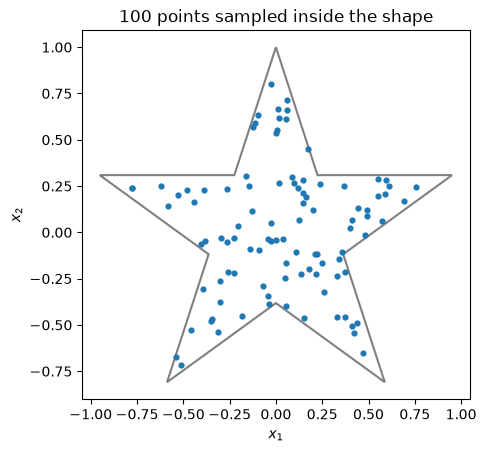

In [2]:
# The shape: any matplotlib patch works -- swap in one of the alternatives below
shape = PathPatch(Path.unit_regular_star(5, innerCircle=0.382))
# shape = Circle((0, 0), radius=1)
# shape = Ellipse((0, 0), width=2, height=1)
# shape = RegularPolygon((0, 0), numVertices=6, radius=1)

# The patch's path in data coordinates, and its bounding box
shape_path = shape.get_path().transformed(shape.get_transform())
(x0, y0), (x1, y1) = shape_path.get_extents().get_points()

n_datapts = 100
points = np.empty((0, 2))
while len(points) < n_datapts:
    cand = rng.uniform([x0, y0], [x1, y1], size=(4 * n_datapts, 2))
    points = np.vstack([points, cand[shape_path.contains_points(cand)]])
points = points[:n_datapts]

fig, ax = plt.subplots(figsize=(5, 5))
ax.add_patch(PathPatch(shape_path, facecolor="none", edgecolor="gray", lw=1.5))
ax.scatter(points[:, 0], points[:, 1], s=12, color="tab:blue")
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(f"{n_datapts} points sampled inside the shape")
plt.show()

## Encode the points and take the mean

Each 2D point is mapped to an SSP vector. Averaging the embeddings bundles all
sampled locations into a single vector. The `length_scale` sets the width of
each point's similarity kernel — keep it small relative to the shape's size
(here the shape spans roughly 2 units).

In [3]:
ssp_space = HexagonalSSPSpace(domain_dim=2, ssp_dim=1015, length_scale=0.1, rng=0)

ssps = ssp_space.encode(points)  # (n_datapts, ssp_dim)
mean_ssp = ssps.mean(axis=0, keepdims=True)
ssps.shape, mean_ssp.shape

((100, 1015), (1, 1015))

## Similarity map of the mean SSP

Encode a grid covering the domain and take the dot product of each grid SSP
with the mean vector. The high-similarity region recovers the star.

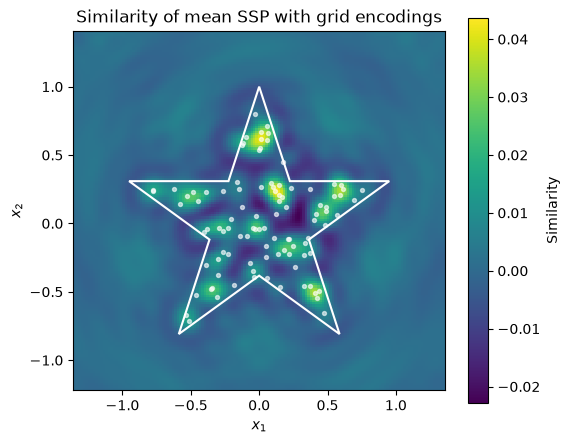

In [4]:
grid_n = 151
pad = 0.4
xs = np.linspace(x0 - pad, x1 + pad, grid_n)
ys = np.linspace(y0 - pad, y1 + pad, grid_n)
X, Y = np.meshgrid(xs, ys)
grid_pts = np.column_stack([X.ravel(), Y.ravel()])
grid_ssps = ssp_space.encode(grid_pts)
sims = (grid_ssps @ mean_ssp.T).reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.pcolormesh(X, Y, sims, cmap="viridis", shading="auto")
ax.add_patch(PathPatch(shape_path, facecolor="none", edgecolor="white", lw=1.5))
ax.scatter(points[:, 0], points[:, 1], s=8, color="white", alpha=0.6)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Similarity of mean SSP with grid encodings")
fig.colorbar(im, ax=ax, label="Similarity")
plt.show()

**Encoding.** A Hex-SSP maps $x\in\mathbb{R}^2$ to

$$\phi(x) = \mathcal{F}^{-1}\!\big[\exp(i\,A x)\big]\in\mathbb{R}^{d},$$

where $A$ is the `(ssp_dim, 2)` phase matrix. The kernel $k(x,x')=\phi(x)\cdot\phi(x')$ is
*stationary* (depends only on $x-x'$).

**Modulation.** Insert a per-frequency gain $g$ (a diagonal in the Fourier domain):

$$\tilde\phi(x) = \mathcal{F}^{-1}\!\big[\,g\odot\exp(i\,A x)\big].$$

If $g$ is constant we just reshape the (still stationary) kernel. If $g$ depends on **location**,
the kernel becomes non-stationary:

$$\tilde k(x,x') = \tfrac1d\sum_k g_k(x)\,g_k(x')\,e^{\,iA_k(x'-x)}.$$

We keep $g$ **block-constant across scales** and conjugate-symmetric (so $\tilde\phi$ stays real).

In [5]:
import jax
import jax.numpy as jnp
import optax

d = ssp_space.ssp_dim
n_scales = ssp_space.n_scales

# Scale block of each rfft half-spectrum coefficient: the phase matrix rows are
# [DC; K; -flip(K)] with K rotation-major and, within a rotation, the scales
# contiguous in groups of (domain_dim + 1) simplex phases.
blk = ssp_space.domain_dim + 1
scale_idx = np.tile(np.repeat(np.arange(n_scales), blk), ssp_space.n_rotates)
assert np.allclose(np.linalg.norm(ssp_space.phase_matrix[1:1 + (d - 1) // 2], axis=1),
                   ssp_space.scales[scale_idx])


def expand_gains(g_scales):
    """Expand per-scale gains (..., n_scales) to rfft half-spectrum gains
    (..., d//2 + 1), block-constant across scales, with the DC gain fixed at 1.
    Real gains on the half spectrum keep the modulated SSPs real."""
    dc = jnp.ones((*g_scales.shape[:-1], 1))
    return jnp.concatenate([dc, g_scales[..., scale_idx]], axis=-1)


def modulate(ssps, g):
    """Apply per-frequency gains g (real, rfft half-spectrum) to already-encoded
    SSP embeddings: phi_tilde = irfft(g * rfft(phi))."""
    return jnp.fft.irfft(g * jnp.fft.rfft(ssps, axis=-1), n=ssps.shape[-1], axis=-1)


grid_ssps_j = jnp.asarray(grid_ssps, dtype=jnp.float32)
mean_ssp_j = jnp.asarray(mean_ssp, dtype=jnp.float32)

# apply to the grid and mean embeddings: with unit gains modulation is the identity
mod_grid = modulate(grid_ssps_j, expand_gains(jnp.ones(n_scales)))
mod_mean = modulate(mean_ssp_j, expand_gains(jnp.ones(n_scales)))
print("identity with g = 1:",
      np.allclose(mod_grid, grid_ssps, atol=1e-5),
      np.allclose(mod_mean, mean_ssp, atol=1e-6))

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


identity with g = 1: True True


## Optimizing a location-dependent gain $g(x)$

The target is the ideal similarity map: 1 inside the shape, 0 everywhere else,
normalized to unit norm. We learn one gain per scale block at every grid
location (`g_grid`, shape `(n_grid_pts, n_scales)`) and a single gain vector
for the mean SSP (`g_mean`), minimizing the total squared difference between
the modulated similarity map and the target with optax's Adam optimizer.

In [6]:
# Ideal similarity map: 1 inside the shape, 0 outside, unit norm
target = shape_path.contains_points(grid_pts).astype(np.float32)
target = target / np.linalg.norm(target)
target_j = jnp.asarray(target)


def loss_fn(params):
    mod_grid = modulate(grid_ssps_j, expand_gains(params["g_grid"]))
    mod_mean = modulate(mean_ssp_j, expand_gains(params["g_mean"]))
    sims = (mod_grid @ mod_mean.T).ravel()
    return jnp.sum((sims - target_j) ** 2)


params = {"g_grid": jnp.ones((grid_pts.shape[0], n_scales)),
          "g_mean": jnp.ones((1, n_scales))}
optimizer = optax.adam(learning_rate=1e-2)
opt_state = optimizer.init(params)


@jax.jit
def step(params, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    return optax.apply_updates(params, updates), opt_state, loss


n_steps = 300
losses = np.empty(n_steps)
for i in range(n_steps):
    params, opt_state, loss = step(params, opt_state)
    losses[i] = loss
print(f"loss: {losses[0]:.4f} -> {losses[-1]:.5f}")

loss: 1.2004 -> 0.00026


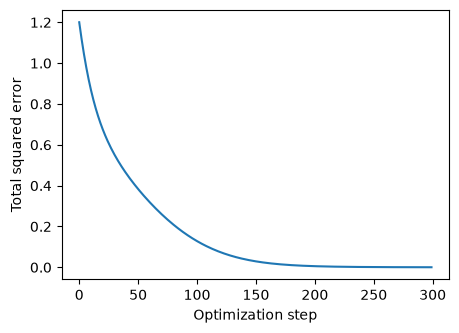

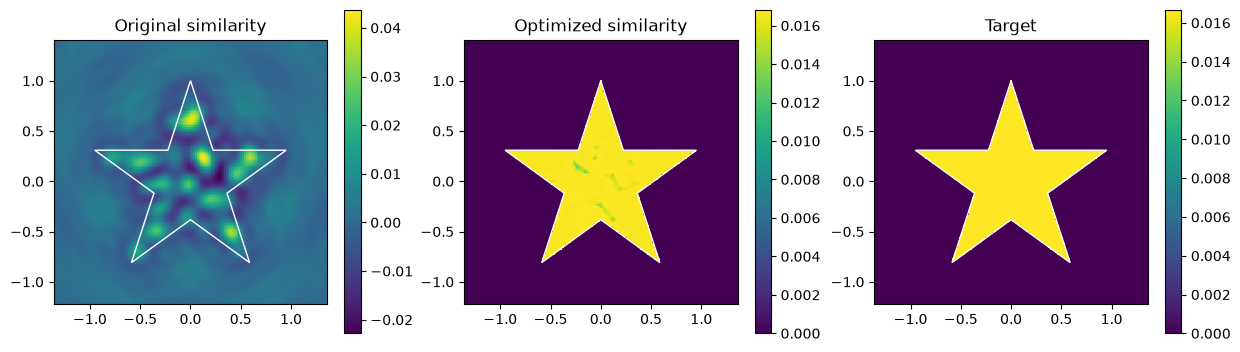

In [7]:
sims_opt = np.asarray(
    modulate(grid_ssps_j, expand_gains(params["g_grid"]))
    @ modulate(mean_ssp_j, expand_gains(params["g_mean"])).T
).reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(losses, color="tab:blue")
ax.set_xlabel("Optimization step")
ax.set_ylabel("Total squared error")
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
panels = [(sims, "Original similarity"),
          (sims_opt, "Optimized similarity"),
          (target.reshape(grid_n, grid_n), "Target")]
for ax, (data, title) in zip(axs, panels):
    im = ax.pcolormesh(X, Y, data, cmap="viridis", shading="auto")
    ax.add_patch(PathPatch(shape_path, facecolor="none", edgecolor="white", lw=1))
    ax.set_aspect("equal")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
plt.show()

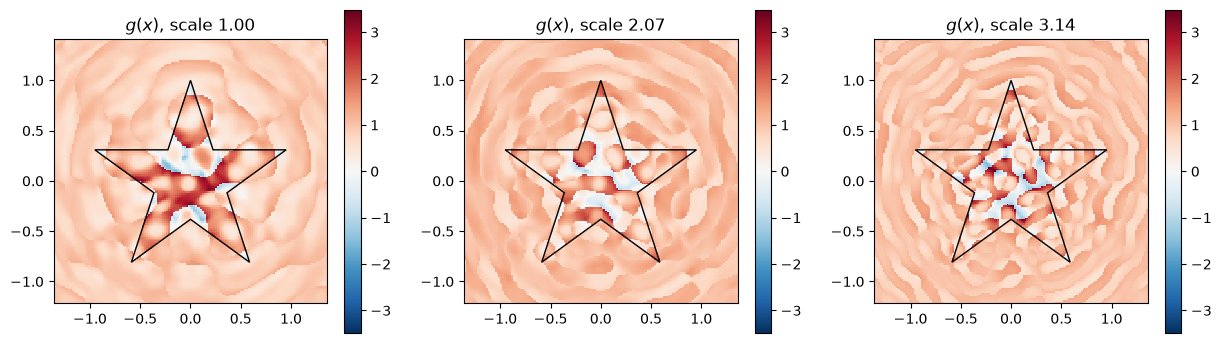

In [8]:
# The learned gain field g(x) for a few of the scale blocks
g_grid = np.asarray(params["g_grid"]).reshape(grid_n, grid_n, n_scales)
show = [0, n_scales // 2, n_scales - 1]
vmax = np.abs(g_grid[..., show]).max()

fig, axs = plt.subplots(1, len(show), figsize=(15, 4.2))
for ax, s in zip(axs, show):
    im = ax.pcolormesh(X, Y, g_grid[..., s], cmap="RdBu_r",
                       vmin=-vmax, vmax=vmax, shading="auto")
    ax.add_patch(PathPatch(shape_path, facecolor="none", edgecolor="black", lw=1))
    ax.set_aspect("equal")
    ax.set_title(f"$g(x)$, scale {ssp_space.scales[s]:.2f}")
    fig.colorbar(im, ax=ax)
plt.show()